# Sentence Embeddings: Bi-Encoders, Cross-Encoders, and Late Interaction

Word embeddings give one vector per word, but retrieval needs to compare whole
*sentences* and *passages*. This notebook is the runnable companion to the book
section "Semantic Similarity with Transformers". It walks the three architectures
that turn a transformer into a retrieval model: the bi-encoder (Sentence-BERT), the
cross-encoder, and the late-interaction model ColBERT.

We start from the problem the book opens with: a transformer produces rich
contextual token vectors, but averaging word vectors into a sentence vector throws
away word order and meaning. We then encode sentences with a bi-encoder, read off a
similarity matrix, watch vocabulary mismatch dissolve, put a cross-encoder next to
the bi-encoder on quality and speed, and finally step through ColBERT MaxSim scoring
on a small example.

**Learning goals:**

- See why averaging word vectors cannot represent sentence meaning
- Encode sentences with a bi-encoder (SBERT) and read a pairwise cosine similarity matrix
- Watch the vocabulary mismatch problem get resolved by contextual embeddings
- Compare a bi-encoder against a cross-encoder on scores and on wall-clock speed
- Step through ColBERT MaxSim scoring token by token

**Prerequisites:** ch05-02 (word embeddings, the polysemy limitation) and ch05-03
(sub-word tokenization and contextual transformer embeddings).

## Setup

We use `sentence-transformers` (which pulls in `transformers` and `torch`),
`scikit-learn` for the cosine matrix, and `matplotlib` for the heatmap. The models
download on first run and are cached afterwards; sizes are noted where each one
loads. We silence the libraries' informational warnings up front.

In [1]:
import os
import time
import logging
import warnings

os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

from shared.display import print_table, display_md

## Why Averaging Word Vectors Fails

The simplest way to turn word vectors into a sentence vector is to average them.
This has a fatal structural flaw: averaging is commutative, so reordering the words
cannot change the result. Two sentences built from the exact same words produce the
exact same average vector, no matter how different their meaning.

We make this concrete with a small set of illustrative word vectors. The point does
not depend on the quality of the vectors: any averaging scheme is order-blind by
construction.

In [2]:
# Assign each distinct word its own fixed vector. Any vectors work; the averaging
# operation itself is what loses word order.
rng = np.random.default_rng(0)
vocab = ["the", "cat", "sat", "on", "mat", "dog", "bit", "man"]
word_vectors = {w: rng.standard_normal(50) for w in vocab}


def average_vector(sentence):
    """Average the vectors of the words in a sentence (a bag-of-vectors)."""
    tokens = sentence.lower().split()
    vecs = [word_vectors[t] for t in tokens if t in word_vectors]
    return np.mean(vecs, axis=0)


def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

In [3]:
# Same words, opposite roles: subject and object are swapped.
order_pairs = [
    ("the cat sat on the mat", "the mat sat on the cat"),
    ("the dog bit the man", "the man bit the dog"),
]

rows = []
for s1, s2 in order_pairs:
    rows.append([s1, s2, f"{cosine(average_vector(s1), average_vector(s2)):.6f}"])

display_md(
    "**Averaging is order-blind.** Each pair below swaps subject and object, so the "
    "meaning flips, yet both sentences draw on the identical multiset of words:"
)
print_table(rows, headers=["Sentence A", "Sentence B", "Avg-vector cosine"])

**Averaging is order-blind.** Each pair below swaps subject and object, so the meaning flips, yet both sentences draw on the identical multiset of words:

| Sentence A             | Sentence B             |   Avg-vector cosine |
|:-----------------------|:-----------------------|--------------------:|
| the cat sat on the mat | the mat sat on the cat |                   1 |
| the dog bit the man    | the man bit the dog    |                   1 |

The cosine is exactly 1.0: the two averaged vectors are byte-for-byte identical.
A bag of word vectors literally cannot tell "the dog bit the man" from "the man bit
the dog". To represent meaning we need a model that reacts to word order and
context, which is exactly what a transformer encoder does.

## Encoding Sentences with a Bi-Encoder (SBERT)

A **bi-encoder** (Sentence-BERT) passes each sentence through a transformer, mean-pools
the token outputs into one fixed-size vector, and normalizes it to unit length. Two
sentences are compared by the cosine of their vectors. Because the vectors are unit
length, cosine similarity equals the dot product, which is the measure this model was
trained with (the book's "match the measure the model was trained with" rule).

<div style="border-left: 4px solid #0284C7; background: rgba(2, 132, 199, 0.06); padding: 0.6em 0.9em; margin: 0.6em 0; border-radius: 4px;">
<strong style="color:#0284C7; text-transform:uppercase; font-size:0.78em; letter-spacing:0.06em;">One-time model download</strong><br>
The first <code>SentenceTransformer(...)</code> call downloads <code>all-MiniLM-L6-v2</code> (about 90 MB) and caches it under the HuggingFace home (<code>~/.cache/huggingface/</code>). Later runs load it from the cache in a second or two. No manual download step is needed.
</div>

In [4]:
from sentence_transformers import SentenceTransformer

# A small, fast, widely used bi-encoder (6 transformer layers, 384-dim output).
bi_encoder = SentenceTransformer("all-MiniLM-L6-v2")

display_md(
    "**Bi-encoder loaded:** `all-MiniLM-L6-v2`\n\n"
    f"| Property | Value |\n"
    f"|----------|-------|\n"
    f"| Transformer layers | 6 |\n"
    f"| Max sequence length | {bi_encoder.max_seq_length} tokens |\n"
    f"| Embedding dimension | {bi_encoder.get_embedding_dimension()} |"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

**Bi-encoder loaded:** `all-MiniLM-L6-v2`

| Property | Value |
|----------|-------|
| Transformer layers | 6 |
| Max sequence length | 256 tokens |
| Embedding dimension | 384 |

We now encode a set of sentences spanning four topics. Three of them are medical
paraphrases that share almost no vocabulary, which is exactly where keyword matching
breaks down.

In [5]:
sentences = [
    # Medical (three paraphrases, little shared vocabulary)
    "The patient was diagnosed with heart disease.",
    "A cardiac condition was identified in the individual.",
    "The doctor confirmed a cardiovascular problem.",
    # Technology
    "The new processor runs at 5 GHz clock speed.",
    "Modern CPUs reach high clock frequencies.",
    # Nature
    "The river flows through the mountain valley.",
    "A stream runs between the peaks.",
    # Unrelated
    "She baked a chocolate cake for the party.",
    "The stock market fell sharply on Monday.",
]

# normalize_embeddings=True returns unit-length vectors, so dot product = cosine.
embeddings = bi_encoder.encode(sentences, normalize_embeddings=True, show_progress_bar=False)

display_md(f"Encoded **{len(sentences)} sentences** into an array of shape {embeddings.shape}.")

Encoded **9 sentences** into an array of shape (9, 384).

## Reading the Pairwise Similarity Matrix

The cosine similarity matrix shows which sentences the model places close together.
Semantically related sentences form bright blocks even when they share no words.

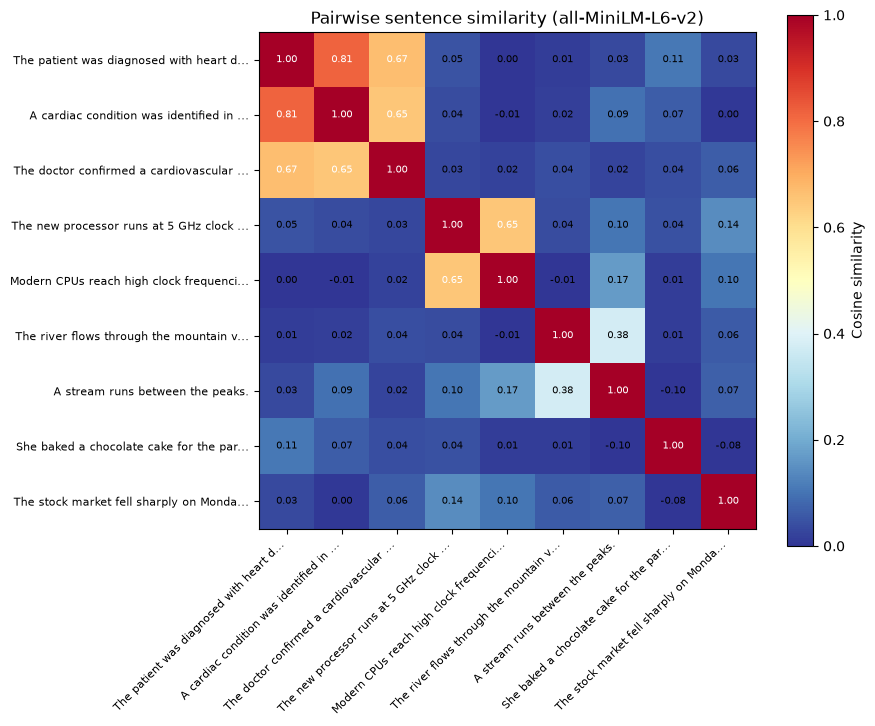

In [6]:
sim_matrix = cosine_similarity(embeddings)

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(sim_matrix, cmap="RdYlBu_r", vmin=0, vmax=1)

labels = [s[:38] + "..." if len(s) > 38 else s for s in sentences]
ax.set_xticks(range(len(sentences)))
ax.set_yticks(range(len(sentences)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(labels, fontsize=8)

for i in range(len(sentences)):
    for j in range(len(sentences)):
        value = sim_matrix[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center",
                fontsize=7, color="white" if value > 0.6 else "black")

plt.colorbar(im, ax=ax, label="Cosine similarity")
ax.set_title("Pairwise sentence similarity (all-MiniLM-L6-v2)", fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
# Pull out the within-topic and across-topic averages to summarize the heatmap.
groups = {"Medical": [0, 1, 2], "Technology": [3, 4], "Nature": [5, 6]}

rows = []
for name, idx in groups.items():
    pairs = [sim_matrix[i, j] for i in idx for j in idx if i < j]
    rows.append([name, len(idx), f"{np.mean(pairs):.3f}"])

# Average similarity between sentences from different topics.
cross = [sim_matrix[i, j]
         for a in groups.values() for b in groups.values() if a is not b
         for i in a for j in b]

display_md(
    "**Within-topic sentences cluster, across-topic sentences do not.** "
    f"The average cosine between sentences from *different* topics is only "
    f"{np.mean(cross):.3f}, while each topic holds together much more tightly:"
)
print_table(rows, headers=["Topic", "Sentences", "Mean within-topic cosine"])

**Within-topic sentences cluster, across-topic sentences do not.** The average cosine between sentences from *different* topics is only 0.041, while each topic holds together much more tightly:

| Topic      |   Sentences |   Mean within-topic cosine |
|:-----------|------------:|---------------------------:|
| Medical    |           3 |                      0.711 |
| Technology |           2 |                      0.651 |
| Nature     |           2 |                      0.376 |

The three medical sentences form a tight cluster even though one says "heart disease",
another "cardiac condition", and the third "cardiovascular problem". The bi-encoder
scores them as near-synonyms. That is the vocabulary mismatch problem dissolving.

## Vocabulary Mismatch, Resolved

Keyword retrieval fails when the query and the relevant document describe the same
thing with different words. A bi-encoder scores meaning, not surface tokens, so pairs
with no shared words can still land close together.

In [8]:
mismatch_pairs = [
    ("heart disease", "cardiac condition"),
    ("car accident", "automobile collision"),
    ("global warming", "climate change"),
    ("quick brown fox", "fast auburn animal"),
    ("buy a house", "purchase a home"),
]

left = bi_encoder.encode([a for a, _ in mismatch_pairs], normalize_embeddings=True, show_progress_bar=False)
right = bi_encoder.encode([b for _, b in mismatch_pairs], normalize_embeddings=True, show_progress_bar=False)

rows = [[a, b, f"{float(np.dot(left[i], right[i])):.3f}"]
        for i, (a, b) in enumerate(mismatch_pairs)]

display_md("**Different words, same meaning.** Cosine similarity on phrase pairs that share no tokens:")
print_table(rows, headers=["Phrase A", "Phrase B", "Cosine similarity"])

**Different words, same meaning.** Cosine similarity on phrase pairs that share no tokens:

| Phrase A        | Phrase B             |   Cosine similarity |
|:----------------|:---------------------|--------------------:|
| heart disease   | cardiac condition    |               0.779 |
| car accident    | automobile collision |               0.613 |
| global warming  | climate change       |               0.77  |
| quick brown fox | fast auburn animal   |               0.535 |
| buy a house     | purchase a home      |               0.859 |

## Cross-Encoders and Reranking

A **cross-encoder** feeds the query and the document through the transformer *together*,
as `[CLS] query [SEP] document [SEP]`, and reads a relevance score off the `[CLS]`
output. Every token in both texts attends to every other token, so the cross-encoder
captures fine-grained interactions the bi-encoder misses. The price: it cannot
pre-compute document vectors. Each query-document pair needs its own forward pass,
so cross-encoders are used to **rerank** the top candidates from a fast first stage,
not to search the whole collection.

<div style="border-left: 4px solid #0284C7; background: rgba(2, 132, 199, 0.06); padding: 0.6em 0.9em; margin: 0.6em 0; border-radius: 4px;">
<strong style="color:#0284C7; text-transform:uppercase; font-size:0.78em; letter-spacing:0.06em;">One-time model download</strong><br>
The first <code>CrossEncoder(...)</code> call downloads <code>cross-encoder/ms-marco-MiniLM-L-6-v2</code> (about 90 MB), a reranker trained on the MS MARCO passage ranking data. It is cached alongside the bi-encoder.
</div>

In [9]:
from sentence_transformers import CrossEncoder

cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")


def relevance(logits):
    """The reranker emits a raw logit per pair; a sigmoid maps it to 0..1 relevance."""
    return 1.0 / (1.0 + np.exp(-np.asarray(logits)))


display_md(
    "**Cross-encoder loaded:** `cross-encoder/ms-marco-MiniLM-L-6-v2`\n\n"
    "It outputs one relevance logit per (query, passage) pair. We pass that logit "
    "through a sigmoid to read it as a relevance score between 0 and 1."
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

**Cross-encoder loaded:** `cross-encoder/ms-marco-MiniLM-L-6-v2`

It outputs one relevance logit per (query, passage) pair. We pass that logit through a sigmoid to read it as a relevance score between 0 and 1.

### A reranking scenario

The word "cold" is a trap for keyword search here: two passages contain it but have
nothing to do with treating an illness, and one relevant passage never uses the word.
We rank the candidates two ways: by bi-encoder cosine (the fast first stage) and by
cross-encoder relevance (the reranker).

In [10]:
query = "How do I treat a common cold?"
candidates = [
    "Rest, drinking plenty of warm fluids, and getting enough sleep help your body recover from a common cold within a week.",
    "Over-the-counter medicines such as decongestants and pain relievers can ease a sore throat, a blocked nose, and body aches.",
    "The Cold War was a decades-long period of geopolitical tension between the United States and the Soviet Union.",
    "She felt a cold indifference toward the entire project and refused to contribute any further ideas.",
    "A heat wave is expected across the southern region this weekend, with temperatures well above the seasonal average.",
]

# First stage: bi-encoder cosine similarity.
q_vec = bi_encoder.encode(query, normalize_embeddings=True, show_progress_bar=False)
c_vecs = bi_encoder.encode(candidates, normalize_embeddings=True, show_progress_bar=False)
bi_scores = c_vecs @ q_vec

# Reranker: cross-encoder raw logit per pair, then the sigmoid 0..1 relevance.
ce_logits = cross_encoder.predict([(query, c) for c in candidates])
ce_scores = relevance(ce_logits)

bi_rank = {idx: r + 1 for r, idx in enumerate(np.argsort(-bi_scores))}
# Rank by the raw logit; the sigmoid is monotonic, so this is the CE ordering.
ce_rank = {idx: r + 1 for r, idx in enumerate(np.argsort(-ce_logits))}

rows = [[candidates[i][:48] + "...", f"{bi_scores[i]:.3f}", bi_rank[i],
         f"{ce_logits[i]:.2f}", f"{ce_scores[i]:.3f}", ce_rank[i]]
        for i in range(len(candidates))]

display_md(f"**Query:** *{query}*")
print_table(rows, headers=["Candidate", "Bi cosine", "Bi rank", "CE logit", "CE relevance", "CE rank"])

**Query:** *How do I treat a common cold?*

| Candidate                                           |   Bi cosine |   Bi rank |   CE logit |   CE relevance |   CE rank |
|:----------------------------------------------------|------------:|----------:|-----------:|---------------:|----------:|
| Rest, drinking plenty of warm fluids, and gettin... |       0.615 |         1 |       4.95 |          0.993 |         1 |
| Over-the-counter medicines such as decongestants... |       0.472 |         2 |      -9.6  |          0     |         2 |
| The Cold War was a decades-long period of geopol... |       0.251 |         3 |     -10.23 |          0     |         3 |
| She felt a cold indifference toward the entire p... |       0.084 |         5 |     -10.82 |          0     |         4 |
| A heat wave is expected across the southern regi... |       0.085 |         4 |     -11.4  |          0     |         5 |

Both rankings put the genuinely on-topic passages on top, so the bi-encoder is already
a strong first stage: unlike keyword search, it is not fooled by the word "cold" in the
Cold War and "cold indifference" passages and scores them low. The cross-encoder, reading
query and passage together, is more decisive still: it rates the passage that directly
describes recovering from a cold far above the rest. That precision at the top of the list
is what reranking buys.

The raw logit column repays a close look. The sigmoid relevance saturates: any logit below
about -7.6 maps to 0.000, so candidates 2 to 5 all read 0.000 even though their logits
differ. The logit exposes the ordering the sigmoid hides, and it shows the reranker still
ranks candidate 2 (the over-the-counter medicines passage) second, above the three true
distractors.

<div style="border-left: 4px solid #64748B; background: rgba(100, 116, 139, 0.06); padding: 0.6em 0.9em; margin: 0.6em 0; border-radius: 4px;">
<strong style="color:#64748B; text-transform:uppercase; font-size:0.78em; letter-spacing:0.06em;">Model relevance is not human relevance</strong><br>
A person reading candidate 2 would call it relevant: over-the-counter decongestants and pain relievers do ease the symptoms of a cold. The cross-encoder scores it near zero anyway, and the raw logit confirms this is a genuine model judgement, not just the sigmoid rounding down. ms-marco leans on topical and lexical alignment, and candidate 2 never names the illness, so the model misses the inference a human draws from world knowledge: model relevance is not the same as human relevance. The reranker still orders candidate 2 above the true distractors (the Cold War, cold-indifference, and heat-wave passages), so its relative ranking is right even though its absolute score is badly low. An LLM-based reranker, with broader world knowledge and reasoning, would likely recognize candidate 2 as relevant where this smaller cross-encoder does not.
</div>

### Where the two diverge most

The gap is clearest when a passage is on topic but does not answer the question. We
score individual (query, passage) pairs with the bi-encoder (cosine) and the
cross-encoder (relevance).

In [11]:
rel_pairs = [
    ("What is the capital of France?", "Paris is the capital and most populous city of France.", "direct answer"),
    ("What is the capital of France?", "France is famous for its wine, cheese, and fashion houses.", "same topic, no answer"),
    ("How tall is Mount Everest?", "Mount Everest rises about 8,849 metres above sea level.", "direct answer"),
    ("How tall is Mount Everest?", "Hundreds of climbers have died attempting to reach the summit of Everest.", "same topic, no answer"),
    ("He deposited money at the bank.", "The boat is tied up near the river bank.", "polysemy, unrelated"),
]

q_side = bi_encoder.encode([q for q, _, _ in rel_pairs], normalize_embeddings=True, show_progress_bar=False)
p_side = bi_encoder.encode([p for _, p, _ in rel_pairs], normalize_embeddings=True, show_progress_bar=False)
pair_bi = [float(np.dot(q_side[i], p_side[i])) for i in range(len(rel_pairs))]
pair_ce = relevance(cross_encoder.predict([(q, p) for q, p, _ in rel_pairs]))

rows = [[q, p[:46] + "...", note, f"{pair_bi[i]:.3f}", f"{pair_ce[i]:.3f}"]
        for i, (q, p, note) in enumerate(rel_pairs)]

display_md("**Bi-encoder cosine vs cross-encoder relevance, (query, passage) pairs:**")
print_table(rows, headers=["Query", "Passage", "Relation", "Bi cosine", "CE relevance"])

**Bi-encoder cosine vs cross-encoder relevance, (query, passage) pairs:**

| Query                           | Passage                                           | Relation              |   Bi cosine |   CE relevance |
|:--------------------------------|:--------------------------------------------------|:----------------------|------------:|---------------:|
| What is the capital of France?  | Paris is the capital and most populous city of... | direct answer         |       0.755 |          1     |
| What is the capital of France?  | France is famous for its wine, cheese, and fas... | same topic, no answer |       0.565 |          0.04  |
| How tall is Mount Everest?      | Mount Everest rises about 8,849 metres above s... | direct answer         |       0.721 |          1     |
| How tall is Mount Everest?      | Hundreds of climbers have died attempting to r... | same topic, no answer |       0.375 |          0.016 |
| He deposited money at the bank. | The boat is tied up near the river bank....       | polysemy, unrelated   |       0.288 |          0     |

The bi-encoder measures topical similarity, so a passage that is clearly about France
or about Everest scores fairly high even when it never answers the question. The
cross-encoder reads query and passage together and judges whether the passage actually
answers the query, so it demotes the "same topic, no answer" passages sharply. Both
agree the polysemy pair is unrelated. Where they disagree is exactly where reranking
earns its cost.

## Speed: the Reason for the Two-Stage Pipeline

The bi-encoder encodes each document once, at index time, so a query only costs one
encode plus a dot product per document. The cross-encoder pre-computes nothing: it runs
a full transformer pass for every query-document pair at query time. Separating index
time from query time makes the difference clear.

In [12]:
n = 200
corpus = [f"Document number {i} describes an unrelated everyday topic." for i in range(n)]

# INDEX TIME (done once, offline): the bi-encoder pre-computes one vector per document.
start = time.perf_counter()
corpus_vecs = bi_encoder.encode(corpus, normalize_embeddings=True, show_progress_bar=False)
index_time = time.perf_counter() - start

# QUERY TIME, bi-encoder: encode the query once, then one dot product per document.
start = time.perf_counter()
qv = bi_encoder.encode(query, normalize_embeddings=True, show_progress_bar=False)
_ = corpus_vecs @ qv
bi_query_time = time.perf_counter() - start

# QUERY TIME, cross-encoder: a full transformer pass for every (query, document) pair.
start = time.perf_counter()
_ = cross_encoder.predict([(query, d) for d in corpus])
ce_query_time = time.perf_counter() - start

display_md(
    f"**Scoring one query against {n} pre-indexed documents:**\n\n"
    f"| Stage | Total time | Per document |\n"
    f"|-------|-----------|--------------|\n"
    f"| Bi-encoder index time (once, offline) | {index_time * 1000:.0f} ms | {index_time / n * 1000:.2f} ms |\n"
    f"| Bi-encoder query time (encode query + dot products) | {bi_query_time * 1000:.1f} ms | {bi_query_time / n * 1000:.3f} ms |\n"
    f"| Cross-encoder query time (one pass per pair) | {ce_query_time * 1000:.0f} ms | {ce_query_time / n * 1000:.2f} ms |\n\n"
    f"The bi-encoder pays its cost once at index time. At query time it only encodes the "
    f"query and runs dot products, making it about **{ce_query_time / bi_query_time:.0f}x** "
    f"faster per query than the cross-encoder here. The gap grows with the collection: the "
    f"cross-encoder must run a full forward pass for every candidate, which is why it reranks "
    f"a short list rather than scanning everything."
)

**Scoring one query against 200 pre-indexed documents:**

| Stage | Total time | Per document |
|-------|-----------|--------------|
| Bi-encoder index time (once, offline) | 94 ms | 0.47 ms |
| Bi-encoder query time (encode query + dot products) | 3.5 ms | 0.017 ms |
| Cross-encoder query time (one pass per pair) | 161 ms | 0.81 ms |

The bi-encoder pays its cost once at index time. At query time it only encodes the query and runs dot products, making it about **46x** faster per query than the cross-encoder here. The gap grows with the collection: the cross-encoder must run a full forward pass for every candidate, which is why it reranks a short list rather than scanning everything.

## ColBERT: Late Interaction with MaxSim

ColBERT sits between the two. Like a bi-encoder it encodes query and document
independently, so documents can be pre-computed. But instead of pooling each text to
one vector, it keeps **one vector per token**. Scoring uses **MaxSim**: every query
token takes its best match among the document tokens, and the score sums those best
matches.

$$
\text{score}(q, d) = \sum_{i=1}^{|q|} \max_{j=1}^{|d|} \mathbf{q}_i^\top \mathbf{d}_j
$$

The vectors here are *contextual* token embeddings, not static word vectors: the token
"bank" already carries its financial-or-river sense from the surrounding words. To
illustrate the arithmetic we take real per-token embeddings from the bi-encoder's
transformer (unit-normalized), compute the full query-by-document similarity grid, and
read MaxSim off it.

<div style="border-left: 4px solid #64748B; background: rgba(100, 116, 139, 0.06); padding: 0.6em 0.9em; margin: 0.6em 0; border-radius: 4px;">
<strong style="color:#64748B; text-transform:uppercase; font-size:0.78em; letter-spacing:0.06em;">Conceptual illustration</strong><br>
A production ColBERT model trains its token embeddings specifically for MaxSim, so synonym matches are sharper than what these raw encoder outputs show. We reuse the bi-encoder's token outputs only to demonstrate the scoring mechanism without a second heavy download.
</div>

In [13]:
def token_embeddings(text):
    """Return (token strings, unit-normalized token vectors) with special tokens dropped."""
    ids = bi_encoder.tokenizer(text, truncation=True)["input_ids"]
    toks = bi_encoder.tokenizer.convert_ids_to_tokens(ids)
    vecs = bi_encoder.encode(text, output_value="token_embeddings").cpu().numpy()
    keep = [i for i, t in enumerate(toks) if t not in ("[CLS]", "[SEP]", "[PAD]")]
    toks = [toks[i] for i in keep]
    vecs = vecs[keep]
    vecs = vecs / np.linalg.norm(vecs, axis=1, keepdims=True)
    return toks, vecs

In [14]:
q_text = "the car crash on the highway"
d_text = "an automobile accident along the motorway"

q_toks, q_emb = token_embeddings(q_text)
d_toks, d_emb = token_embeddings(d_text)

# Full token-by-token similarity grid, then MaxSim per query token.
grid = q_emb @ d_emb.T                 # shape (|q|, |d|)
best_j = grid.argmax(axis=1)
max_sims = grid.max(axis=1)
total = float(max_sims.sum())

rows = [[q_toks[i], d_toks[best_j[i]], f"{max_sims[i]:.3f}"] for i in range(len(q_toks))]

display_md(
    f"**MaxSim scoring, token by token.** Query: *{q_text}* / Document: *{d_text}*\n\n"
    f"Each query token keeps its single best match in the document; the score is the sum.\n\n"
    f"ColBERT score = **{total:.3f}** (sum over {len(q_toks)} query tokens)"
)
print_table(rows, headers=["Query token", "Best document token", "Max similarity"])

**MaxSim scoring, token by token.** Query: *the car crash on the highway* / Document: *an automobile accident along the motorway*

Each query token keeps its single best match in the document; the score is the sum.

ColBERT score = **4.015** (sum over 6 query tokens)

| Query token   | Best document token   |   Max similarity |
|:--------------|:----------------------|-----------------:|
| the           | an                    |            0.662 |
| car           | automobile            |            0.702 |
| crash         | accident              |            0.721 |
| on            | along                 |            0.565 |
| the           | the                   |            0.703 |
| highway       | motorway              |            0.662 |

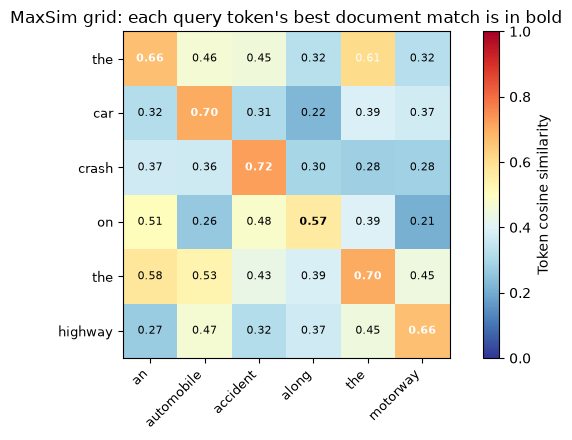

In [15]:
# The same grid as a heatmap: rows are query tokens, columns are document tokens.
fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(grid, cmap="RdYlBu_r", vmin=0, vmax=1)

ax.set_xticks(range(len(d_toks)))
ax.set_yticks(range(len(q_toks)))
ax.set_xticklabels(d_toks, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(q_toks, fontsize=9)

for i in range(len(q_toks)):
    for j in range(len(d_toks)):
        value = grid[i, j]
        weight = "bold" if j == best_j[i] else "normal"
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8,
                fontweight=weight, color="white" if value > 0.6 else "black")

plt.colorbar(im, ax=ax, label="Token cosine similarity")
ax.set_title("MaxSim grid: each query token's best document match is in bold")
plt.tight_layout()
plt.show()

Unlike the bi-encoder, nothing is pooled away: each token keeps its own vector, so
a strong match on one important token lifts the score even when the surrounding words
differ. Unlike the cross-encoder, query and document are still encoded separately, so
document token vectors can be computed ahead of time. That is the middle ground ColBERT
occupies.

## Summary

| Architecture | Document representation | Query-time cost per document | Quality |
|---|---|---|---|
| Bi-encoder | one pooled vector | one dot product | good |
| ColBERT | one vector per token | $\lvert q \rvert \times n$ dot products | very good |
| Cross-encoder | none, re-encodes the pair | a full transformer pass | excellent |

<div style="border-left: 4px solid #C8102E; background: rgba(200, 16, 46, 0.06); padding: 0.6em 0.9em; margin: 0.6em 0; border-radius: 4px;">
<strong style="color:#C8102E; text-transform:uppercase; font-size:0.78em; letter-spacing:0.06em;">Takeaway</strong><br>
Averaging word vectors throws away order and meaning. A bi-encoder encodes a whole sentence into one vector and compares with cosine, fast enough to search millions of documents and good enough to resolve vocabulary mismatch. A cross-encoder reads query and document together for the best quality but pays a full forward pass per pair, so it reranks a short list. ColBERT keeps per-token vectors and scores with MaxSim, buying most of the cross-encoder's quality while still allowing documents to be pre-computed.
</div>

## Try It Yourself

In [16]:
# 1. Encode your own sentences and find the most similar pair.
my_sentences = [
    "The weather is beautiful today.",
    "It is sunny and warm outside.",
    "The stock market is volatile this week.",
    # Add your own sentences here.
]

my_vecs = bi_encoder.encode(my_sentences, normalize_embeddings=True, show_progress_bar=False)
my_sims = cosine_similarity(my_vecs)
np.fill_diagonal(my_sims, 0.0)
i, j = np.unravel_index(my_sims.argmax(), my_sims.shape)

display_md(
    "**Most similar pair in your set:**\n\n"
    f"- \"{my_sentences[i]}\"\n"
    f"- \"{my_sentences[j]}\"\n"
    f"- Cosine similarity: {my_sims[i, j]:.3f}"
)

**Most similar pair in your set:**

- "The weather is beautiful today."
- "It is sunny and warm outside."
- Cosine similarity: 0.688

In [17]:
# 2. Rerank your own candidates for a query and compare the two orderings.
def rerank(query, candidates):
    q = bi_encoder.encode(query, normalize_embeddings=True, show_progress_bar=False)
    c = bi_encoder.encode(candidates, normalize_embeddings=True, show_progress_bar=False)
    bi = c @ q
    ce = relevance(cross_encoder.predict([(query, cand) for cand in candidates]))
    rows = [[candidates[k][:50], f"{bi[k]:.3f}", f"{ce[k]:.3f}"] for k in np.argsort(-ce)]
    print_table(rows, headers=["Candidate (reranked)", "Bi cosine", "CE relevance"])

rerank(
    "best programming language for beginners",
    [
        "Python is often recommended as a first programming language.",
        "The weather forecast predicts rain tomorrow.",
        "Many beginners start coding with a simple scripting language.",
    ],
)

| Candidate (reranked)                               |   Bi cosine |   CE relevance |
|:---------------------------------------------------|------------:|---------------:|
| Many beginners start coding with a simple scriptin |       0.689 |          0.996 |
| Python is often recommended as a first programming |       0.692 |          0.987 |
| The weather forecast predicts rain tomorrow.       |      -0.007 |          0     |